In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Dataset
import torchvision
import numpy as np
import matplotlib.pyplot as plt
import random
import os
#from video_to_tensor import video_a_tensor_gris_redimensionado
import pandas as pd
from IPython.display import clear_output

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

device

device(type='cuda')

In [3]:
def set_seed(seed=42):
    # 1. Python puro
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    # 2. NumPy
    np.random.seed(seed)
    
    # 3. PyTorch (CPU y GPU)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # Si usas múltiples GPUs
    
    # 4. Configuración de algoritmos de cuDNN
    # Esto asegura que las operaciones de la GPU sean deterministas
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [4]:
#set_seed(42)

In [6]:
class CNN_LSTM_Model(nn.Module):
    def __init__(self, input_channels, output_features, num_layers, hidden_size, output_size):
        super(CNN_LSTM_Model, self).__init__()

        # 1. Definir la Red Neuronal Convolucional (CNN)
        # Esto será el extractor de características para cada fotograma (paso de tiempo).
        self.cnn = nn.Sequential(
            nn.Conv2d(input_channels, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(),

            nn.Conv2d(8, output_features, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)


            # La salida de esto será (Batch_Size, output_features, H', W')
        )
        self.dropout = nn.Dropout(0.25) # Define dropout layer

        #print("fin de conv2d")
        # Calcular el tamaño del vector de características aplanado
        # (Necesitarás hacer un forward pass con un tensor simulado para obtener el tamaño exacto
        # si las dimensiones de entrada H y W son variables).
        # Por simplicidad, asumiremos que H' * W' es 'feature_dim'
        feature_dim = output_features * 32 * 32  # Ajusta estos números según tu entrada real (H' x W')

        # 2. Definir la capa LSTM
        self.lstm = nn.LSTM(
            input_size = feature_dim, # La entrada es el vector aplanado de la CNN
            hidden_size = hidden_size,
            num_layers = num_layers,
            batch_first = True        # El formato de entrada será (B, T, F)
        )

        # 3. Definir la capa de Salida
        self.fc = nn.Linear(hidden_size, output_size)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # x.shape es (B, T, C, H, W)
        B, T, C, H, W = x.size()
        #print("x size",x.shape)
        # Reestructurar: Combinar Batch y Tiempo para aplicar la CNN
        # Ahora x.shape es (B * T, C, H, W)
        c_in = x.view(B * T, C, H, W)

        # Aplicar la CNN
        c_out = self.cnn(c_in)
        # c_out.shape es (B * T, C', H', W')

        #c_out = self.dropout(c_in)

        # Aplanar la salida de la CNN para que sea un vector (F)
        # Ahora c_out.shape es (B * T, Feature_Dim)
        r_in = c_out.view(B * T, -1)

        # Reestructurar de nuevo: Separar Batch y Tiempo para la LSTM
        # Ahora r_in.shape es (B, T, Feature_Dim)
        r_in = r_in.view(B, T, -1)

        # Aplicar la LSTM
        r_out, (h_n, h_c) = self.lstm(r_in)
        # r_out.shape es (B, T, Hidden_Size) si return_sequences=True (por defecto)

        # Usar solo la salida del último paso de tiempo para la clasificación/regresión
        # Ahora r_out.shape es (B, Hidden_Size)
        r_out = r_out[:, -1, :]


        # Aplicar la capa de Salida
        output = self.fc(r_out)
        return output #r_out


In [ ]:

#dataset = TensorDataset(X, y)
#dataloader = DataLoader(dataset, batch_size=32, shuffle=True)
#modelo = CNN_LSTM_Model(3,8,1,64,3*20) 
# 1. Definir la ruta del archivo
PATH = "modelos/m2/molelo130.pth"

modelo = CNN_LSTM_Model(3,8,1,64,2*20) # modelo que predice x,y
modelo.to(device)
criterion = nn.MSELoss()
criterion_bce = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(modelo.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

# 3. Cargar el diccionario completo
checkpoint = torch.load(PATH, map_location=device)

# 4. Asignar los estados guardados a los objetos locales
modelo.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

# 5. Recuperar variables adicionales (opcional)
epoch = checkpoint['epoch']
loss = checkpoint['loss']

print(f"Modelo cargado exitosamente desde la época {epoch}", loss)



Modelo cargado exitosamente desde la época 100 tensor(0.0002, device='cuda:0', requires_grad=True)


In [8]:
class PreBatchedDataset(Dataset):
    def __init__(self, files):
        self.files = files

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        data = torch.load(self.files[idx], map_location="cpu")
        return data["X"], data["y"]


In [9]:
import glob

#batch_files = sorted(glob.glob("tensors/3_estrellas/envy_baby/batch_*.pt"))
batch_files = sorted(glob.glob("tensors/3_estrellas/envy_baby/batch_*.pt"))
print(len(batch_files))

i = 10

#batch_files = batch_files[1:2]

523


In [ ]:
dataset = PreBatchedDataset(
    batch_files,
)

loader = DataLoader(
    dataset,
    batch_size=1,
    shuffle=True,
    num_workers=0
)




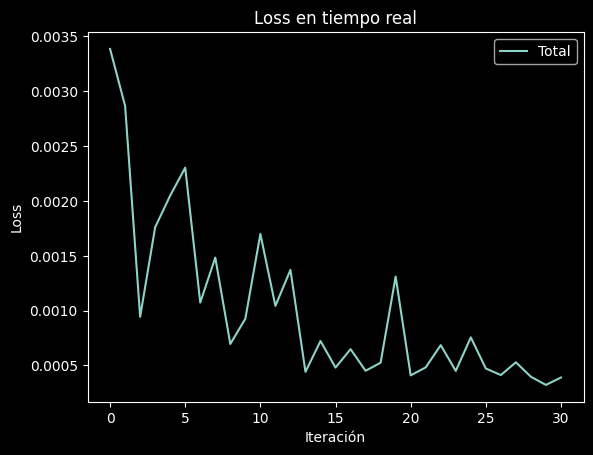

Epoch 132, loss: 0.0004
0
x: 749 y: 421 c:
1
x: 1101 y: 619 c:
2
x: 1369 y: 770 c:
3
x: 1360 y: 765 c:
4
x: 785 y: 441 c:
5
x: 1041 y: 585 c:
6
x: 1707 y: 960 c:
7
x: 479 y: 269 c:
8
x: 1150 y: 646 c:
9
x: 391 y: 220 c:
10
x: 975 y: 548 c:
11
x: 441 y: 248 c:
12
x: 961 y: 540 c:
13
x: 790 y: 444 c:
14
x: 983 y: 553 c:
15
x: 991 y: 557 c:
16
x: 1415 y: 796 c:
17
x: 1237 y: 696 c:
18
x: 377 y: 212 c:
19
x: 755 y: 424 c:
20
x: 1416 y: 796 c:
21
x: 1549 y: 871 c:
22
x: 1456 y: 819 c:
23
x: 1233 y: 693 c:
24
x: 757 y: 426 c:
25
x: 1061 y: 597 c:
26
x: 670 y: 376 c:
27
x: 401 y: 225 c:
28
x: 561 y: 315 c:
29
x: 1130 y: 636 c:
30
x: 436 y: 245 c:
31
x: 1268 y: 713 c:
32
x: 1284 y: 722 c:
33
x: 1473 y: 829 c:
34
x: 841 y: 473 c:
35
x: 1258 y: 708 c:
36
x: 839 y: 472 c:
37
x: 259 y: 145 c:
38
x: 1115 y: 627 c:
39
x: 1511 y: 850 c:
40
x: 694 y: 390 c:
41
x: 469 y: 264 c:
42
x: 516 y: 290 c:
43
x: 1365 y: 767 c:
44
x: 686 y: 386 c:
45
x: 1489 y: 837 c:
46
x: 542 y: 305 c:
47
x: 358 y: 201 c:
48
x

ValueError: cannot convert float NaN to integer

In [11]:

epochs = 200 + checkpoint['epoch']

loss_history = []

for epoch in range(checkpoint['epoch']+1,epochs):
    k = 0
    for X, y in loader:
        print(k)
        k += 1
        #print(y.squeeze(0).shape, X.squeeze(0).shape)
        X = X.squeeze(0).to(device)   # (B, 32, C, H, W)

        y = y.squeeze(0).view((32,40)).to(device)   # (B, 2)
        #y = y.squeeze(0).to(device)
        

        


        optimizer.zero_grad()

        pred = modelo(X)
        #print(pred.shape,y.shape)

        print("x:",int( pred[0][1].item() * 1920) ,"y:",int(pred[0][1].item() * 1080),"c:")
        loss = criterion(pred, y)

        loss.backward()
        optimizer.step()
            
    loss_history.append(loss.item())

    # Graficar en "tiempo real"
    clear_output(wait=True)
    plt.plot(loss_history)


    plt.xlabel("Iteración")
    plt.ylabel("Loss")
    plt.title("Loss en tiempo real")
    plt.legend(["Total"])
    plt.show()  

    print(f"Epoch {epoch+1}, loss: {loss.item():.4f}")

    if(epoch%10 == 0 and epoch!= 0):

        torch.save({
                'epoch': epoch,
                'model_state_dict': modelo.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'loss': loss
                }, f"modelos/m2/molelo{epoch}.pth")

    
